## HSIC lasso for node pruning

### Date: 05.11.2024

Summary of steps:

1- take X_t and y_t as the outcome of neurons and outputs

2- Apply the HSIC_lasso and Identify the list of potential nodes for pruning, e.g., nodes with Zero coefficient

3- Report the RMSE error for the applied pruning




### To run under the given previous virtual env the following lib should be installed:
#### pip install pyHSICLassop

In [1]:
# pip install hyperopt jupyter matplotlib pandas requests reservoirpy scikit-learn seaborn brevitas fxpmath

In [2]:
# pip install pyHSICLasso

In [3]:
import numpy as np
from reservoirpy.observables import rmse, rsquare

Reservoir Size 200: RMSE=0.0008, R^2=1.0000, MSE=0.0000, NRMSE=0.0004

Summary of Results:
N=200 | RMSE=0.0008 | R^2=1.0000 | MSE=0.0000 | NRMSE=0.0004


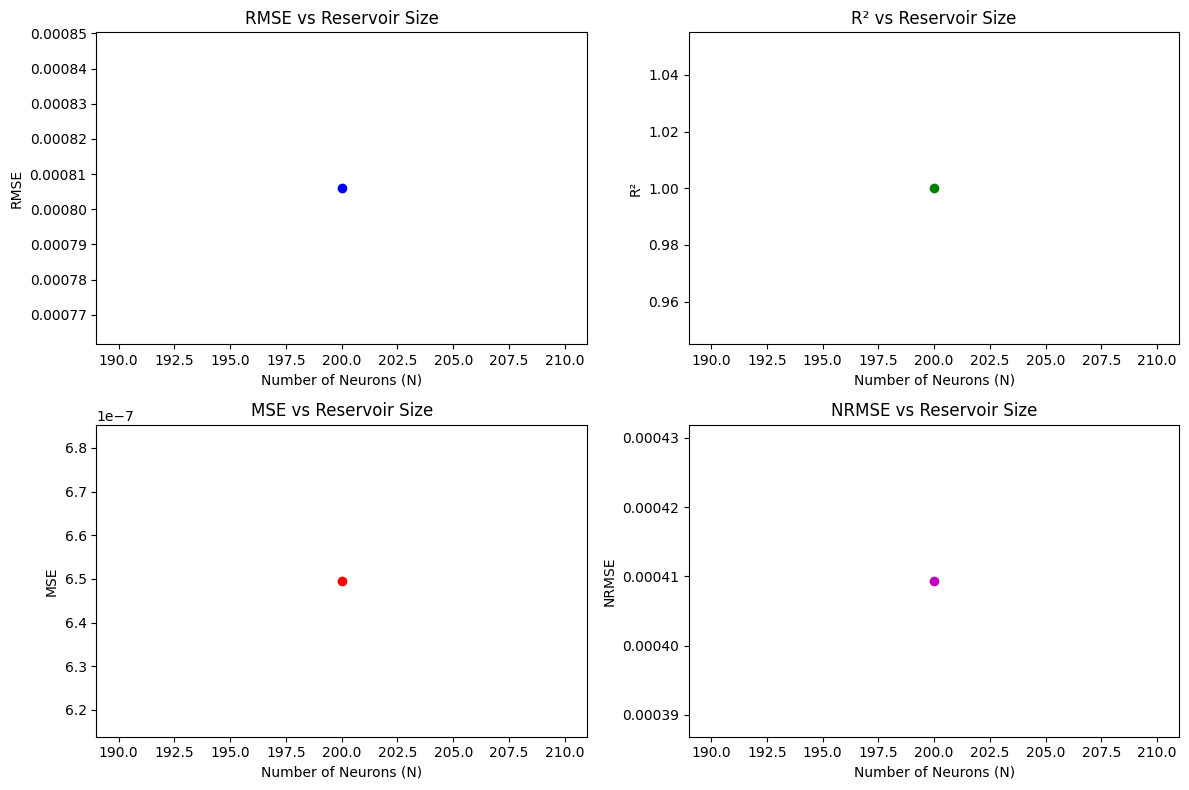

In [4]:
import numpy as np
import torch
from reservoirpy.datasets import lorenz
from reservoirpy.nodes import Reservoir, Ridge
import matplotlib.pyplot as plt
import reservoirpy as rpy
from reservoirpy.observables import rmse, rsquare, mse, nrmse

# Set seed for reproducibility
rpy.set_seed(42)

# Parameters for NARMA10 task


rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!
X = lorenz(10000)
X = 2 * (X - X.min()) / (X.max() - X.min()) - 1

train_len = 5000
forecast = 1

X_train = X[:train_len]
Y_train = X[forecast : train_len + forecast]

X_test = X[train_len : -forecast]
Y_test = X[train_len + forecast:]
# Experiment with different reservoir sizes (units)
# reservoir_sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]  # Increase the reservoir size incrementally
reservoir_sizes = [200]
# Performance tracking
results = []

# Loop through different reservoir sizes to find the best
for N in reservoir_sizes:
    # Reservoir and readout configurations
    reservoir = Reservoir(
        units=N,  # Use 'units' instead of 'N' for number of neurons
        lr=1,          # Leaking rate: Small to ensure enough memory
        sr=0.9,         # Spectral radius close to 1 for stable dynamics
        input_connectivity=0.34,  # High input-to-reservoir connectivity
        rc_connectivity=0.1,     # Low internal connectivity for simplicity
        input_scaling=1        # Input scaling to help with learning
    )
    
    # Ridge regularization for the readout
    readout = Ridge(ridge=1e-1)  # Ridge regularization
    # readout.ridge=1e-4
    # Combine reservoir and readout to form the ESN model
    esn_model = reservoir >> readout

    # Fit the model (with warmup period)
    esn_model = esn_model.fit(X_train, Y_train, warmup=1000)

    # Run the model to predict outputs
    # Y_pred = esn_model.run(X_test)
    reservoir_states_test = reservoir.run(X_test)  # Shape: (time_steps, num_neurons).
    reservoir_states_test.shape
    np.save('reservoir_states_test', reservoir_states_test)
    output_test = readout.run(reservoir_states_test)  # Shape: (time_steps, output_dim)
    output_test.shape
    np.save('output_test', output_test)
    # Calculate performance metrics
    rmse_val = rmse(Y_test, output_test)
    r2_score = rsquare(Y_test, output_test)
    mse_val = mse(Y_test, output_test)
    nrmse_val = nrmse(Y_test, output_test)  # Fix for proper NRMSE calculation

    # Save results for comparison
    results.append({
        "N": N,
        "RMSE": rmse_val,
        "R^2": r2_score,
        "MSE": mse_val,
        "NRMSE": nrmse_val
    })
    print(f"Reservoir Size {N}: RMSE={rmse_val:.4f}, R^2={r2_score:.4f}, MSE={mse_val:.4f}, NRMSE={nrmse_val:.4f}")

# Print out the results for all reservoir sizes
print("\nSummary of Results:")
for result in results:
    print(f"N={result['N']} | RMSE={result['RMSE']:.4f} | R^2={result['R^2']:.4f} | MSE={result['MSE']:.4f} | NRMSE={result['NRMSE']:.4f}")

# Plot results to visualize how reservoir size impacts performance
sizes = [result['N'] for result in results]
rmse_vals = [result['RMSE'] for result in results]
r2_vals = [result['R^2'] for result in results]
mse_vals = [result['MSE'] for result in results]
nrmse_vals = [result['NRMSE'] for result in results]

# Plot RMSE, R², MSE, and NRMSE vs Reservoir Size
plt.figure(figsize=(12, 8))

# RMSE Plot
plt.subplot(2, 2, 1)
plt.plot(sizes, rmse_vals, marker='o', color='b')
plt.title('RMSE vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('RMSE')

# R² Plot
plt.subplot(2, 2, 2)
plt.plot(sizes, r2_vals, marker='o', color='g')
plt.title('R² vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('R²')

# MSE Plot
plt.subplot(2, 2, 3)
plt.plot(sizes, mse_vals, marker='o', color='r')
plt.title('MSE vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('MSE')

# NRMSE Plot
plt.subplot(2, 2, 4)
plt.plot(sizes, nrmse_vals, marker='o', color='m')
plt.title('NRMSE vs Reservoir Size')
plt.xlabel('Number of Neurons (N)')
plt.ylabel('NRMSE')

plt.tight_layout()
plt.show()



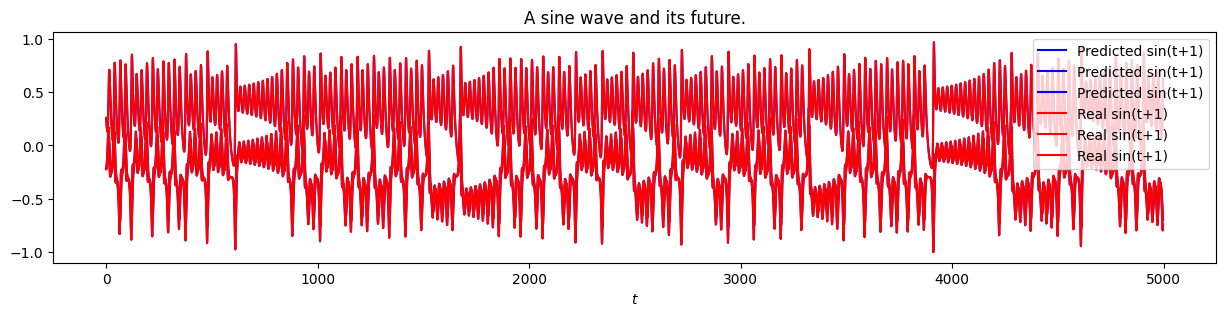

Original RMSE: 0.0007823848667689274 R^2 score: 0.9999955740510045


In [5]:
X_train = X[:5000]
Y_train = X[1:5001]
X_test = X[5001:-1]
Y_test = X[5002:]
esn_model = esn_model.fit(X_train, Y_train, warmup=400

)
 #states of each time stamp over test set
reservoir_states_test = reservoir.run(X_test)  # Shape: (time_steps, num_neurons).
reservoir_states_test.shape
np.save('reservoir_states_test', reservoir_states_test)
output_test = readout.run(reservoir_states_test)  # Shape: (time_steps, output_dim)
output_test.shape
np.save('output_test', output_test)
plt.figure(figsize=(15, 3))
plt.title("A sine wave and its future.")
plt.xlabel("$t$")
plt.plot(output_test, label="Predicted sin(t+1)", color="blue")
plt.plot(Y_test.astype(float), label="Real sin(t+1)", color="red")
plt.legend()
plt.show()
print("Original RMSE:", rmse(output_test, Y_test), "R^2 score:", rsquare(output_test, Y_test))

In [6]:
print(type(reservoir_states_test))
output_test.shape
print(type(reservoir_states_test))
print(reservoir_states_test[:,0].shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(4998,)


/home/atousa/.local/lib/python3.10/site-packages/torch/_tensor.py:1271: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1788.)
  return super().rename(names)


Input int quantized:
 [[ -34  -34  -34]
 [ -34  -32  -34]
 [ -33  -28  -34]
 ...
 [ -80 -101   44]
 [ -86 -102   62]
 [ -89  -95   80]] 

Input scale: 0.0078125
Input zero_point: 0.0
Extract quantized integer Win and Scale and Zero_point
Input int quantized:
 [[ 127    0    0]
 [   0    0    0]
 [-128  127  127]
 [ 127  127 -128]
 [ 127    0    0]
 [   0    0  127]
 [   0  127  127]
 [   0    0    0]
 [   0    0    0]
 [   0    0    0]
 [   0    0    0]
 [   0    0 -128]
 [ 127 -128 -128]
 [   0  127    0]
 [   0 -128 -128]
 [   0    0    0]
 [   0    0    0]
 [-128  127    0]
 [   0  127    0]
 [   0    0    0]
 [ 127 -128    0]
 [   0 -128    0]
 [ 127    0    0]
 [   0    0    0]
 [ 127    0    0]
 [ 127 -128    0]
 [   0    0    0]
 [-128    0 -128]
 [   0    0  127]
 [-128 -128    0]
 [-128 -128    0]
 [-128  127 -128]
 [   0    0    0]
 [   0  127    0]
 [   0    0    0]
 [-128    0    0]
 [   0    0  127]
 [   0    0 -128]
 [   0 -128    0]
 [   0    0 -128]
 [   0  127 -128]
 [

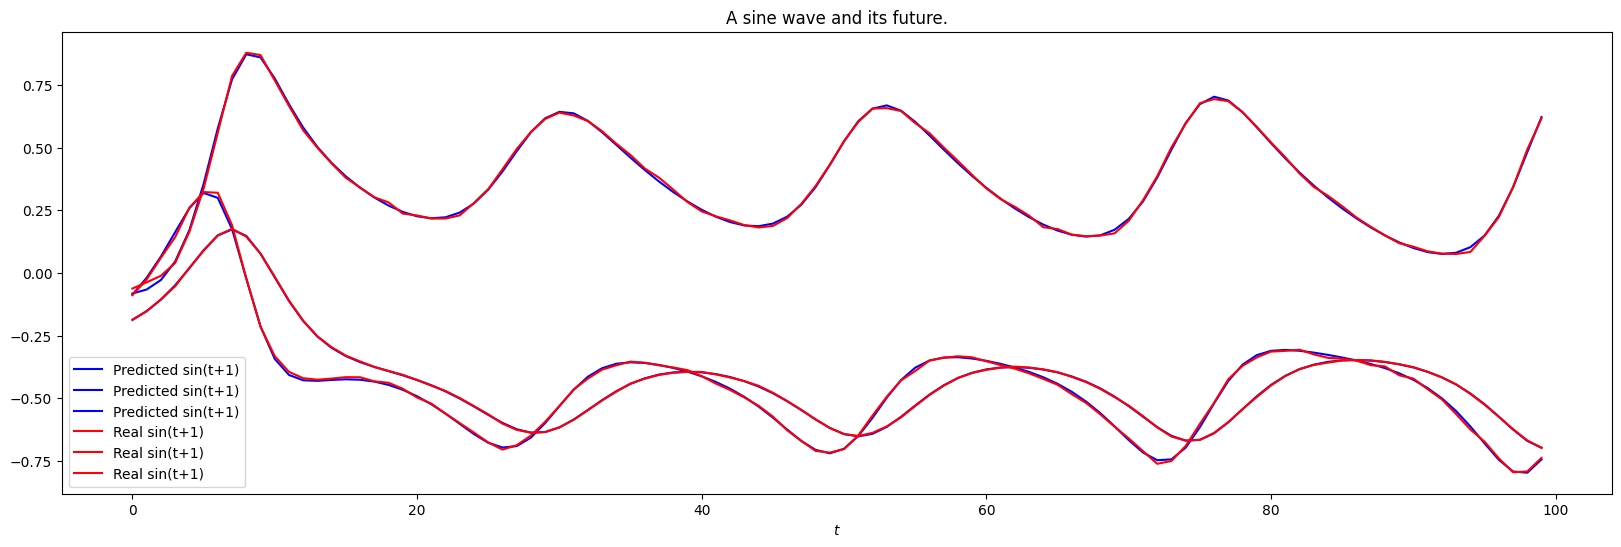

RMSE: for combine 0.0020902831539592404 R^2 score: 0.9999736422842235


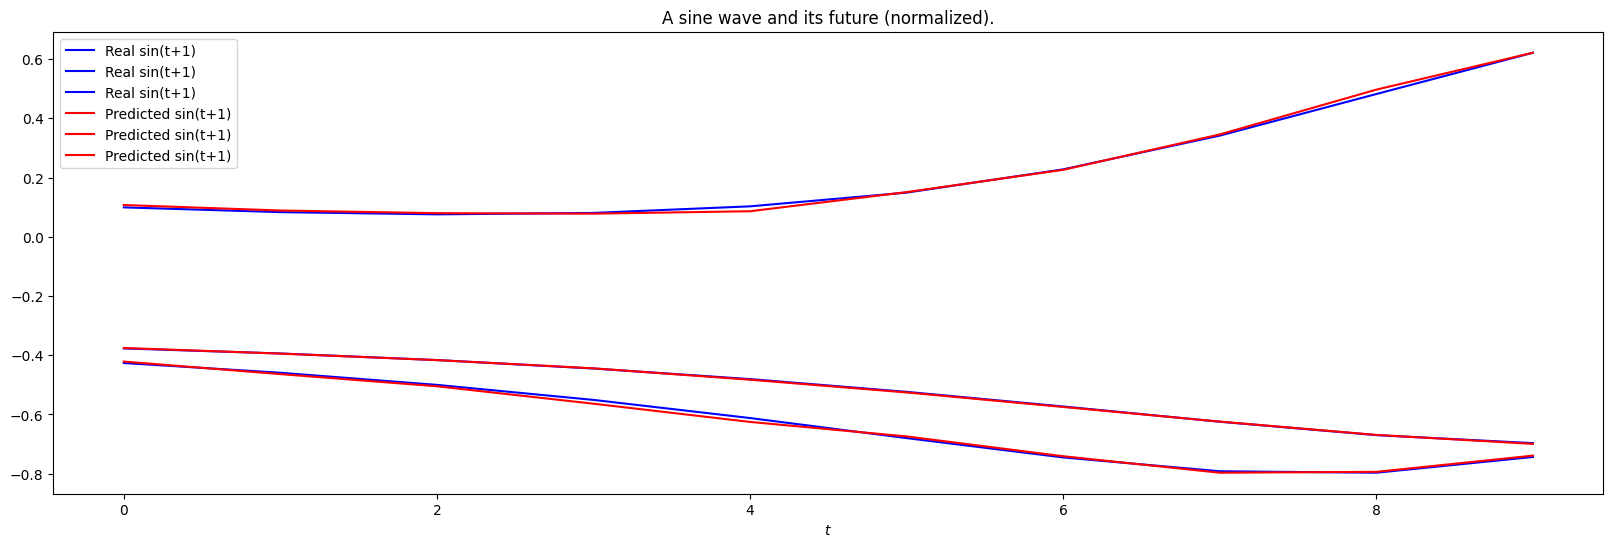

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from brevitas.nn import QuantHardTanh, QuantIdentity, QuantLinear
from brevitas.quant import Int8ActPerTensorFloat, Int8WeightPerTensorFloat
from reservoirpy.datasets import mackey_glass
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import rmse, rsquare
from reservoirpy import Node
import reservoirpy as rpy
rpy.verbosity(0)
rpy.set_seed(42)
# pruned_res_size = len(ind)

# # Parameters
# N = pruned_res_size #reservoir size
bit_width = 8 # quantization bit width
#integer, out , scale,  quantizer, layer , ...
# input

from brevitas.nn import QuantIdentity
import math
def extract_Qinput(input, num_bits=8):
  quant_identity = QuantIdentity(return_quant_tensor=True,bit_width=num_bits)
  float_input = torch.tensor(input,dtype=torch.float64)
  quant_input = quant_identity(float_input)
  out = quant_input.int().detach().numpy()

  scale = quant_input.scale.detach().numpy()
  zero_point = quant_input.zero_point.numpy()
  print(f"Input int quantized:\n {out} \n")
  print(f"Input scale: {scale}")
  print(f"Input zero_point: {zero_point}")
  return out, scale, zero_point
from brevitas.nn import QuantLinear
from brevitas.quant import Int8ActPerTensorFloat,Int8WeightPerTensorFloat
import math


def quantize_output_layer(weights, num_bits=8):
  quant_linear = QuantLinear(2, 4,weight_bit_width=num_bits, weight_quant=Int8WeightPerTensorFloat, requires_grad=False)
  quant_linear.weight.data = torch.tensor(weights,dtype=torch.float64)

  out = quant_linear.quant_weight().int().detach().numpy()
  scale = quant_linear.quant_weight().scale.detach().numpy()
  # out = quant_linear.quant_weight().value.data.numpy()


  #out = out * 0

  return out,scale

int_x,x_scale,x_zero_point = extract_Qinput(X,num_bits=bit_width)
np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
print('Extract quantized integer Win and Scale and Zero_point')
int_Win,scale_Win,zero_point_Win = extract_Qinput(esn_model.nodes[0].Win.todense(),num_bits=bit_width)
print('Extract quantized integer Wr and Scale and Zero_point')
int_Wr,scale_Wr,zero_point_Wr = extract_Qinput(esn_model.nodes[0].W.todense(),num_bits=bit_width)
int_bias, scale_bias, zero_point_bias = extract_Qinput(esn_model.nodes[0].bias.todense(), num_bits=bit_width)


input_scale = (scale_Win * x_scale)
threshold_scale = 0.0078125
reservoir_scale = (scale_Wr * threshold_scale)

def compute_integer_thresholds(scale):

    a = -1  # Lower bound of Hard Tanh
    b = 1   # Upper bound of Hard Tanh
    a_scaled = np.int32(a / scale)
    b_scaled = np.int32(b / scale)
    return a_scaled, b_scaled

def piecewise_linear_hard_tanh_integer(x, a_scaled, b_scaled):

    # Apply saturation logic
    x = np.where(x < a_scaled, a_scaled, x)
    x = np.where(x > b_scaled, b_scaled, x)
    x=x + b_scaled
    return (x / 256).astype(np.int32)

a_scaled, b_scaled = compute_integer_thresholds(input_scale)
c_scaled, d_scaled = compute_integer_thresholds(reservoir_scale)

def forward2(node: Node, x: np.ndarray) -> np.ndarray:
    state = node.state()  # get current node state  # Current reservoir state as integer
    state_int = state.astype(np.int64)
    W_res = node.Wr
    W_in = node.Win
    bias_res = node.Bias
    state_int = state_int.reshape(1,N)

    r = state_int @ W_res.astype(np.int32)
    s = x @ W_in.astype(np.int32).T
    s = s.reshape(1,N)
    # Precompute thresholds and scale
    # a_scaled, b_scaled = compute_integer_thresholds(scale_Wr)
    bias_res = bias_res.reshape(1, N)



    # Apply integer PLA to reservoir and input contributions
    out_r = piecewise_linear_hard_tanh_integer(s,a_scaled, b_scaled)
    out_s = piecewise_linear_hard_tanh_integer(r,c_scaled, d_scaled)

    return out_r + out_s 

def initialize(node: Node, x: np.ndarray = None, y: np.ndarray = None):
    """This function receives a data point x at runtime and uses it to
    infer input and output dimensions.
    """
    if x is not None:
        node.set_input_dim(x.shape[1])
        node.set_output_dim(N)
        node.set_param("Wr", int_Wr)
        node.set_param("Win", int_Win)
        node.set_param("Bias", int_bias)

class CustomNode(Node):
    def __init__(self, const2=-1, name=None):
        super().__init__(
            forward=forward2,
            initializer=initialize,

            params={"const1": None, "Wr":None, "Win":None, "Bias":None},
            hypers={"const2": const2},
            name=name,
        )

node = CustomNode(const2=-1, name="custom_node3")
# readout_pruned.ridge = 1e-12

esn_model_PTQ = node >> readout

Quantized_States = node.run(int_x[:5000].astype(np.float64))

Quantized_States = Quantized_States * threshold_scale
readout.fit(Quantized_States.astype(np.float64), X[1:5001].astype(np.float64), warmup=1000)
# esn_model_PTQ = node >> readout_pruned

# esn_model_PTQ = esn_model_PTQ.fit(int_x[:5000].astype(np.float64), int_x[1:5001].astype(np.float64), warmup=1000)

Quantized_States = node.run(int_x[5001:-1].astype(np.float64))
Quantized_States = Quantized_States * threshold_scale
Y_pred_PTQ_origin = readout.run(Quantized_States.astype(np.float64))
min_pred = np.min(Y_pred_PTQ_origin)
max_pred = np.max(Y_pred_PTQ_origin)
Y_pred_PTQ_normalized = 2 * (Y_pred_PTQ_origin - min_pred) / (max_pred - min_pred) - 1

# Wout_quantized, scale_out = quantize_output_layer(readout.Wout,num_bits=bit_width)
# readout.Wout = Wout_quantized

# a=threshold_scale * scale_out

# Y_pred_PTQ = esn_model_PTQ.run(int_x[5001:-1])
# Y_pred_PTQ = Y_pred_PTQ *a

from reservoirpy.observables import rmse, rsquare

#print("RMSE:", rmse(X[5002:], Y_pred_PTQ), "R^2 score:", rsquare(X[5002:], Y_pred_PTQ))

plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future.")
plt.xlabel("$t$")
plt.plot(X[-100:], label="Predicted sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ_origin[-100:], label="Real sin(t+1)", color="red")
plt.legend()
plt.show()

min_x = np.min(X[-10:])
max_x = np.max(X[-10:])
min_pred = np.min(Y_pred_PTQ_origin[-10:])
max_pred = np.max(Y_pred_PTQ_origin[-10:])

Y_pred_PTQ_origin_normalized = (Y_pred_PTQ_origin[-10:] - min_pred) / (max_pred - min_pred) * (max_x - min_x) + min_x

print("RMSE: for combine", rmse(Y_pred_PTQ_origin[-10:], Y_pred_PTQ_origin_normalized), "R^2 score:", rsquare(Y_pred_PTQ_origin[-10:], Y_pred_PTQ_origin_normalized))

plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future (normalized).")
plt.xlabel("$t$")
plt.plot(X[-10:], label="Real sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ_origin_normalized, label="Predicted sin(t+1)", color="red")
plt.legend()
plt.show()

In [8]:
import numpy as np
from pyHSICLasso import HSICLasso
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

n,o, d = 4999,3,N # n samples, d features
np.random.seed(0)
M = reservoir_states_test # Input matrix -> here should be the outcome of neurons
y = Y_test[:, 0].reshape(-1, 1) # Output of the ESN network
    # Normalize the input data
scaler = StandardScaler()
M = scaler.fit_transform(M)
M_train, M_test, y_train, y_test = train_test_split(M, y, test_size=0.5, random_state=42)

# Iterate over the number of features
best_features = None
best_rmse_diff = float(0.5)  # Difference between current RMSE and target RMSE
int_list_temp=[]
for num_features in range(1, d):
    print(num_features)
    hsic_lasso = HSICLasso()

    # Run HSIC Lasso to select a specific number of features
    hsic_lasso.input(M_train, y_train.reshape(-1))
    hsic_lasso.regression(num_feat=num_features)
    # hsic_lasso.plot()
    hsic_lasso.dump()

    selected_indices = hsic_lasso.get_features()
    selected_indices_temp = set(map(int, selected_indices))
    for i in range(len(selected_indices)):
        selected_indices_temp.update(hsic_lasso.get_index_neighbors(feat_index=i,num_neighbors=5))
        # selected_indices.append(hsic_lasso.get_index_neighbors(feat_index=i,num_neighbors=5))
    selected_indices = sorted(list(selected_indices_temp))
    if not selected_indices:  # Skip iteration if no features were selected
        continue
    # print(f"selected_indices: {selected_indices}")
    model = LinearRegression()
    int_list = list(map(int, selected_indices))
    if (int_list==int_list_temp):
        break
    print(f"int_list: {int_list}")
    ind = [x - 1 for x in int_list]
    print(f"ind: {ind}")
    int_list_temp=int_list
    model.fit(M_train[:, ind], y_train.reshape(-1))

    # Calculate RMSE on the test set
    y_pred = model.predict(M_test[:, ind])
    rmse_hsic = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"Found features with num_features={num_features}, RMSE={rmse_hsic} within tolerance of target RMSE.")

1
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.


/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 70           | 1.000 | 143          (0.972), 195          (0.971), 193          (0.933), 111          (0.932), 23           (0.928)|
int_list: [22, 70, 110, 142, 192, 194]
ind: [21, 69, 109, 141, 191, 193]
Found features with num_features=1, RMSE=0.009031652303720219 within tolerance of target RMSE.
2
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.


/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 70           | 1.000 | 143          (0.972), 195          (0.971), 193          (0.933), 111          (0.932), 23           (0.928)|
| 2     | 149          | 0.043 | 10           (0.964), 177          (0.962), 174          (0.955), 59           (0.938), 69           (0.933)|
int_list: [9, 22, 58, 68, 70, 110, 142, 149, 173, 176, 192, 194]
ind: [8, 21, 57, 67, 69, 109, 141, 148, 172, 175, 191, 193]
Found features with num_features=2, RMSE=0.004092455483443913 within tolerance of target RMSE.
3
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.


...

============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 70           | 1.000 | 143          (0.972), 195          (0.971), 193          (0.933), 111          (0.932), 23           (0.928)|
| 2     | 149          | 0.624 | 10           (0.964), 177          (0.962), 174          (0.955), 59           (0.938), 69           (0.933)|
| 3     | 105          | 0.268 | 112          (0.973), 19           (0.970), 163          (0.969), 111          (0.955), 31           (0.949)|
| 4     | 111          | 0.168 | 109          (0.980), 124          (0.963), 195          (0.955), 105          (0.955), 24           (0.948)|
| 5     | 124          | 0.133 | 109          (0.977), 153          (0.973), 24           (0.968), 111          (0.963), 114          (0.958)|
| 6     | 166          | 0.087 | 177          (0.9

/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 70           | 1.000 | 143          (0.972), 195          (0.971), 193          (0.933), 111          (0.932), 23           (0.928)|
| 2     | 149          | 0.617 | 10           (0.964), 177          (0.962), 174          (0.955), 59           (0.938), 69           (0.933)|
| 3     | 105          | 0.313 | 112          (0.973), 19           (0.970), 163          (0.969), 111          (0.955), 31           (0.949)|
| 4     | 124          | 0.174 | 109          (0.977), 153          (0.973), 24           (0.968), 111          (0.963), 114          (0.958)|
| 5     | 166          | 0.132 | 177          (0.982), 20           (0.964), 153          (0.951), 172          (0.947), 124          (0.938)|
| 6     | 111          | 0.085 | 109          (0.9

/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 2499. Number of blocks 124.95 will be approximated to 124.
  warnings.warn(msg, RuntimeWarning)


============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 70           | 1.000 | 143          (0.972), 195          (0.971), 193          (0.933), 111          (0.932), 23           (0.928)|
| 2     | 149          | 0.615 | 10           (0.964), 177          (0.962), 174          (0.955), 59           (0.938), 69           (0.933)|
| 3     | 105          | 0.310 | 112          (0.973), 19           (0.970), 163          (0.969), 111          (0.955), 31           (0.949)|
| 4     | 124          | 0.185 | 109          (0.977), 153          (0.973), 24           (0.968), 111          (0.963), 114          (0.958)|
| 5     | 166          | 0.139 | 177          (0.982), 20           (0.964), 153          (0.951), 172          (0.947), 124          (0.938)|
| 6     | 143          | 0.087 | 195          (0.9

In [9]:
print("New reservoir size",len(ind))

New reservoir size 33


In [10]:
keep_neurons = ind
pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
pruned_bias = esn_model.nodes[0].bias[keep_neurons,:]

In [11]:
esn_model.nodes[0].W

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4000 stored elements and shape (200, 200)>

In [12]:
pruned_W

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 109 stored elements and shape (33, 33)>

In [13]:
from reservoirpy.nodes import Reservoir
rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!
def create_new_reservoir(model, pruned_W, pruned_W_in, pruned_bias):


    # Create a new reservoir with the pruned configuration
    pruned_reservoir = Reservoir(
        len(pruned_bias.todense()),
        lr=model.nodes[0].lr,
        sr=model.nodes[0].sr,
        input_connectivity=model.nodes[0].input_connectivity,
        # rc_connectivity=model.nodes[0].rc_connectivity,
        input_scaling=(model.nodes[0].input_scaling),
        input_dim=model.nodes[0].input_dim,
        seed=42
    )

    # Assign the pruned weights to the new reservoir
    pruned_reservoir.W = pruned_W
    pruned_reservoir.Win = pruned_W_in
    pruned_reservoir.bias = pruned_bias

    return pruned_reservoir

In [15]:
reservoir_pruned = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)

# readout_pruned = Ridge(ridge=1e-4, output_dim=1,input_bias=True)
readout_pruned.bias=readout.bias
esn_model_pruned = reservoir_pruned >> readout_pruned

readout_pruned.Wout=pruned_W_out
# readout_pruned.bias = readout.bias
esn_model_pruned=esn_model_pruned.fit(X_train, Y_train, warmup=400)
Y_pred_pruned = esn_model_pruned.run(X_test)

# print(f"Testing RMSE after pruning, k step forward:")
# print("RMSE:", rmse(Y_pred_pruned, Y_test), "R^2 score:", rsquare(Y_pred_pruned, Y_test))

ValueError: Ridge-1is  expecting data of shape (1,) but received shape (3,).

In [14]:
reservoir_pruned.params

{'W': <67x67 sparse matrix of type '<class 'numpy.float64'>'
 	with 449 stored elements in Compressed Sparse Row format>,
 'Win': <67x1 sparse matrix of type '<class 'numpy.float64'>'
 	with 60 stored elements in Compressed Sparse Row format>,
 'Wfb': None,
 'bias': <67x1 sparse matrix of type '<class 'numpy.float64'>'
 	with 60 stored elements in Compressed Sparse Row format>,
 'internal_state': array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])}

In [15]:
reservoir_pruned.W = pruned_W
reservoir_pruned.Win = pruned_W_in
reservoir_pruned.bias = pruned_bias

In [16]:
esn_model_pruned=esn_model_pruned.fit(X_train, Y_train, warmup=400)
Y_pred_pruned = esn_model_pruned.run(X_test)

In [17]:
reservoir_pruned.params

{'W': <67x67 sparse matrix of type '<class 'numpy.float64'>'
 	with 442 stored elements in Compressed Sparse Row format>,
 'Win': <67x1 sparse matrix of type '<class 'numpy.float64'>'
 	with 59 stored elements in Compressed Sparse Row format>,
 'Wfb': None,
 'bias': <67x1 sparse matrix of type '<class 'numpy.float64'>'
 	with 60 stored elements in Compressed Sparse Row format>,
 'internal_state': array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])}

In [ ]:
# Main ERROR
from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
import math # Import math library

# Calculate the mean squared error using mean_squared_error from sklearn.metrics
mse = mean_squared_error(Y_pred_pruned, Y_test,warmup=400)

# Raise the mean squared error to the power of 0.5
rmse_pruned = (mse)**(1/2)
# Print the RMSE
print("The calculated Root Mean Square Error (RMSE) Pruned is: " + str(rmse_pruned))

The calculated Root Mean Square Error (RMSE) is: 0.0010234259455899016


In [19]:
print("R^2 score:", rsquare(Y_pred_pruned, Y_test))

R^2 score: 0.9999967162869109


In [ ]:
reservoir_random = Reservoir(len(ind), lr=1, sr=0.9, input_connectivity=0.9,rc_connectivity=0.1,input_scaling=0.1)

readout_random = Ridge(ridge=1e-4)
esn_model_random = reservoir_random >> readout_random

esn_model_random = esn_model_random.fit(X_train, Y_train, warmup=400)
 #states of each time stamp over test set
reservoir_states_test_random = reservoir_random.run(X_test)  # Shape: (time_steps, num_neurons).
reservoir_states_test_random.shape
np.save('reservoir_states_test_random', reservoir_states_test_random)
output_test_random = readout_random.run(reservoir_states_test_random)  # Shape: (time_steps, output_dim)
output_test_random.shape
np.save('output_test_random', output_test_random)
print("RMSE Random Pruned:", rmse(output_test_random, Y_test), "R^2 score:", rsquare(output_test_random, Y_test))

RMSE: 0.007829590915678194 R^2 score: 0.9998071248589003


In [21]:
# plt.figure(figsize=(15, 6))
# plt.title("A sine wave and its future.")
# plt.xlabel("$t$")
# plt.plot(Y_pred_pruned[-100:], label="Predicted sin(t+1)", color="blue")
# plt.plot(Y_test[-100:], label="Real sin(t+1)", color="red")
# plt.legend()
# plt.show()
# print("RMSE:", rmse(Y_pred_pruned[-100:], Y_test[-100:]), "R^2 score:", rsquare(Y_pred_pruned[-100:], Y_test[-100:]))

In [22]:
# # Normalizing result
# min_x = np.min(Y_test)
# max_x = np.max(Y_test)
# min_pred = np.min(Y_pred_pruned)
# max_pred = np.max(Y_pred_pruned)

# Y_pred_Q_normalized = (Y_pred_pruned - min_pred) / (max_pred - min_pred) * (max_x - min_x) + min_x

# print("RMSE:", rmse(Y_test.astype(float), Y_pred_Q_normalized.astype(float)), "R^2 score:", rsquare(Y_test, Y_pred_Q_normalized))

# plt.figure(figsize=(20, 10))
# plt.title("A sine wave and its future (normalized).")
# plt.xlabel("$t$")
# plt.plot(Y_test, label="Real sin(t+1)", color="blue")
# plt.plot(Y_pred_Q_normalized, label="Predicted sin(t+1)", color="red")
# plt.legend()
# plt.show()

# **/////////////////////////////////////Quantization**

In [23]:
readout_pruned.Wout

array([[-2.05649585e-01],
       [ 4.54621395e-01],
       [-1.39822476e-01],
       [ 1.25539303e-01],
       [-2.39786613e-01],
       [-4.80830338e-01],
       [-7.47420050e-01],
       [-1.46573539e-01],
       [ 7.23295450e-01],
       [-8.49027255e-02],
       [ 5.69417357e-01],
       [ 7.32531733e-01],
       [-3.07118198e-01],
       [ 7.96571104e-01],
       [-2.06338140e-01],
       [ 3.00682628e-01],
       [ 1.99154403e-03],
       [-4.13035917e-01],
       [-4.78651933e-01],
       [-7.76326479e-02],
       [ 2.49147840e-02],
       [-1.36227423e-01],
       [ 3.47888403e-01],
       [-2.91465102e-01],
       [-1.26216203e-01],
       [ 6.19449990e-01],
       [-3.44222175e-02],
       [ 1.36899093e+00],
       [ 2.57707044e-01],
       [-1.82146413e-01],
       [ 1.11996737e+00],
       [-3.30692567e-01],
       [-1.53166598e-01],
       [ 5.73771850e-01],
       [ 2.51090660e-01],
       [ 3.43843841e-02],
       [-7.53884985e-03],
       [ 7.94121860e-01],
       [-1.4

Input int quantized:
 [[  1]
 [101]
 [-39]
 ...
 [-32]
 [ 53]
 [ 52]] 

Input scale: 0.0078125
Input zero_point: 0.0
Extract quantized integer Win and Scale and Zero_point
Input int quantized:
 [[   0]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [-128]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [   0]
 [-128]
 [ 127]
 [ 127]
 [ 127]
 [-128]
 [   0]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [   0]
 [-128]
 [-128]
 [   0]
 [-128]
 [ 127]
 [-128]
 [   0]
 [ 127]
 [   0]
 [ 127]
 [ 127]
 [ 127]
 [   0]
 [ 127]
 [-128]
 [-128]
 [-128]
 [-128]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [-128]
 [-128]
 [-128]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [ 127]
 [ 127]
 [-128]
 [-128]
 [ 127]
 [ 127]
 [ 127]
 [-128]
 [ 127]] 

Input scale: 0.0078125
Input zero_point: 0.0
Extract quantized integer Wr and Scale and Zero_point
Input int quantized:
 [[  0   0   0 ... -79   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...

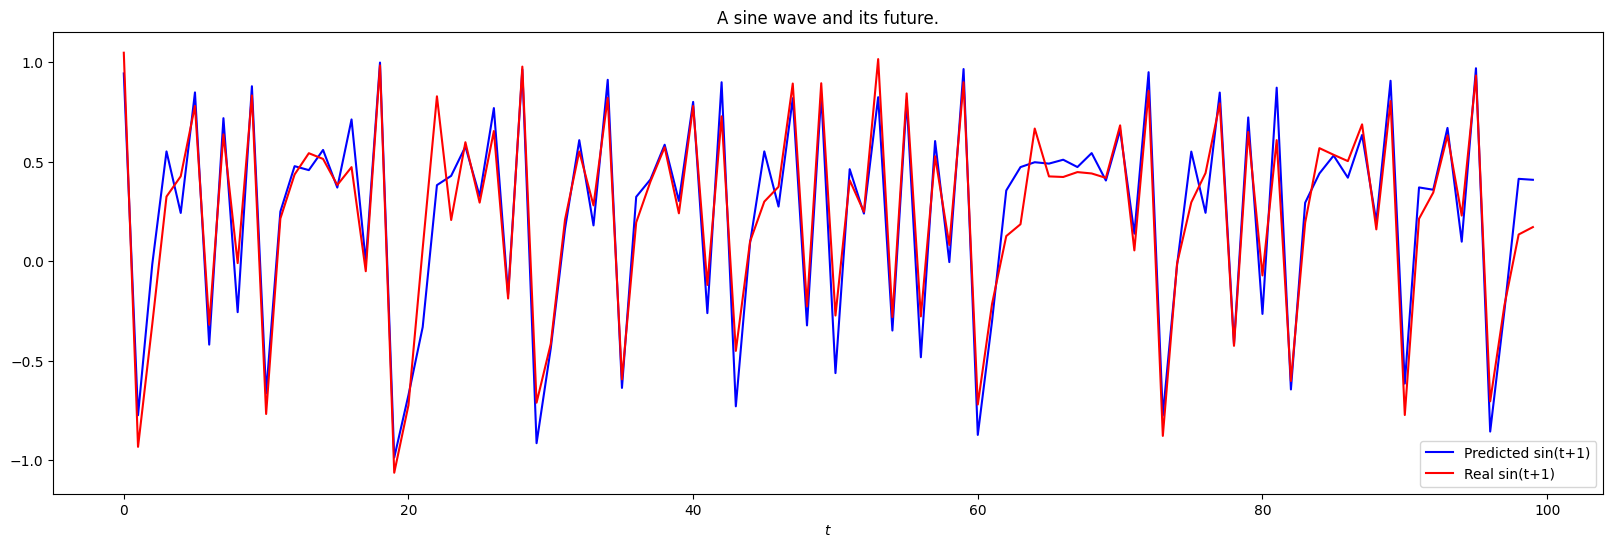

RMSE: for combine 0.04202037606231869 R^2 score: 0.9931697826898938


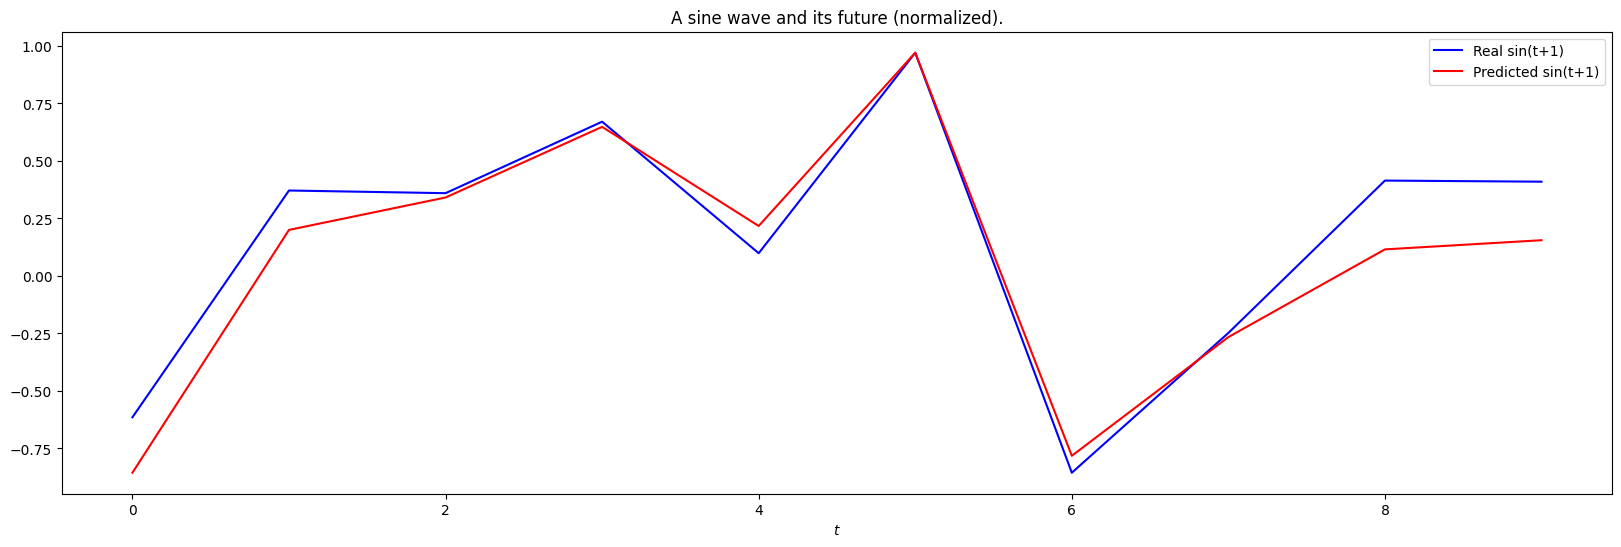

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from brevitas.nn import QuantHardTanh, QuantIdentity, QuantLinear
from brevitas.quant import Int8ActPerTensorFloat, Int8WeightPerTensorFloat
from reservoirpy.datasets import mackey_glass
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import rmse, rsquare
from reservoirpy import Node
import reservoirpy as rpy
rpy.verbosity(0)
rpy.set_seed(42)
pruned_res_size = len(ind)

# Parameters
N = pruned_res_size #reservoir size
bit_width = 8 # quantization bit width
#integer, out , scale,  quantizer, layer , ...
# input

from brevitas.nn import QuantIdentity
import math
def extract_Qinput(input, num_bits=8):
  quant_identity = QuantIdentity(return_quant_tensor=True,bit_width=num_bits)
  float_input = torch.tensor(input,dtype=torch.float64)
  quant_input = quant_identity(float_input)
  out = quant_input.int().detach().numpy()

  scale = quant_input.scale.detach().numpy()
  zero_point = quant_input.zero_point.numpy()
  print(f"Input int quantized:\n {out} \n")
  print(f"Input scale: {scale}")
  print(f"Input zero_point: {zero_point}")
  return out, scale, zero_point
from brevitas.nn import QuantLinear
from brevitas.quant import Int8ActPerTensorFloat,Int8WeightPerTensorFloat
import math


def quantize_output_layer(weights, num_bits=8):
  quant_linear = QuantLinear(2, 4,weight_bit_width=num_bits, weight_quant=Int8WeightPerTensorFloat, requires_grad=False)
  quant_linear.weight.data = torch.tensor(weights,dtype=torch.float64)

  out = quant_linear.quant_weight().int().detach().numpy()
  scale = quant_linear.quant_weight().scale.detach().numpy()
  # out = quant_linear.quant_weight().value.data.numpy()


  #out = out * 0

  return out,scale

int_x,x_scale,x_zero_point = extract_Qinput(X,num_bits=bit_width)
np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
print('Extract quantized integer Win and Scale and Zero_point')
int_Win,scale_Win,zero_point_Win = extract_Qinput(esn_model_pruned.nodes[0].Win.todense(),num_bits=bit_width)
print('Extract quantized integer Wr and Scale and Zero_point')
int_Wr,scale_Wr,zero_point_Wr = extract_Qinput(esn_model_pruned.nodes[0].W.todense(),num_bits=bit_width)
int_bias, scale_bias, zero_point_bias = extract_Qinput(esn_model_pruned.nodes[0].bias.todense(), num_bits=bit_width)


input_scale = (scale_Win * x_scale)
threshold_scale = 0.0078125
reservoir_scale = (scale_Wr * threshold_scale)

def compute_integer_thresholds(scale):

    a = -1  # Lower bound of Hard Tanh
    b = 1   # Upper bound of Hard Tanh
    a_scaled = np.int32(a / scale)
    b_scaled = np.int32(b / scale)
    return a_scaled, b_scaled

def piecewise_linear_hard_tanh_integer(x, a_scaled, b_scaled):

    # Apply saturation logic
    x = np.where(x < a_scaled, a_scaled, x)
    x = np.where(x > b_scaled, b_scaled, x)
    x=x + b_scaled
    return (x / 256).astype(np.int32)

a_scaled, b_scaled = compute_integer_thresholds(input_scale)
c_scaled, d_scaled = compute_integer_thresholds(reservoir_scale)

def forward2(node: Node, x: np.ndarray) -> np.ndarray:
    state = node.state()  # get current node state  # Current reservoir state as integer
    state_int = state.astype(np.int64)
    W_res = node.Wr
    W_in = node.Win
    bias_res = node.Bias
    state_int = state_int.reshape(1,N)

    r = state_int @ W_res.astype(np.int32)
    s = x @ W_in.astype(np.int32).T
    s = s.reshape(1,N)
    # Precompute thresholds and scale
    # a_scaled, b_scaled = compute_integer_thresholds(scale_Wr)
    bias_res = bias_res.reshape(1, N)



    # Apply integer PLA to reservoir and input contributions
    out_r = piecewise_linear_hard_tanh_integer(s,a_scaled, b_scaled)
    out_s = piecewise_linear_hard_tanh_integer(r,c_scaled, d_scaled)

    return out_r + out_s 

def initialize(node: Node, x: np.ndarray = None, y: np.ndarray = None):
    """This function receives a data point x at runtime and uses it to
    infer input and output dimensions.
    """
    if x is not None:
        node.set_input_dim(x.shape[1])
        node.set_output_dim(N)
        node.set_param("Wr", int_Wr)
        node.set_param("Win", int_Win)
        node.set_param("Bias", int_bias)

class CustomNode(Node):
    def __init__(self, const2=-1, name=None):
        super().__init__(
            forward=forward2,
            initializer=initialize,

            params={"const1": None, "Wr":None, "Win":None, "Bias":None},
            hypers={"const2": const2},
            name=name,
        )

node = CustomNode(const2=-1, name="custom_node3")
# readout_pruned.ridge = 1e-12

esn_model_PTQ = node >> readout_pruned

Quantized_States = node.run(int_x[:5000].astype(np.float64))

Quantized_States = Quantized_States * threshold_scale
readout_pruned.fit(Quantized_States.astype(np.float64), X[1:5001].astype(np.float64), warmup=1000)
# esn_model_PTQ = node >> readout_pruned

# esn_model_PTQ = esn_model_PTQ.fit(int_x[:5000].astype(np.float64), int_x[1:5001].astype(np.float64), warmup=1000)

Quantized_States = node.run(int_x[5001:-1].astype(np.float64))
Quantized_States = Quantized_States * threshold_scale
Y_pred_PTQ = readout_pruned.run(Quantized_States.astype(np.float64))
min_pred = np.min(Y_pred_PTQ)
max_pred = np.max(Y_pred_PTQ)
Y_pred_PTQ_normalized = 2 * (Y_pred_PTQ - min_pred) / (max_pred - min_pred) - 1

# Wout_quantized, scale_out = quantize_output_layer(readout.Wout,num_bits=bit_width)
# readout.Wout = Wout_quantized

# a=threshold_scale * scale_out

# Y_pred_PTQ = esn_model_PTQ.run(int_x[5001:-1])
# Y_pred_PTQ = Y_pred_PTQ *a

from reservoirpy.observables import rmse, rsquare

print("RMSE PQ:", rmse(X[5002:], Y_pred_PTQ), "R^2 score:", rsquare(X[5002:], Y_pred_PTQ))

plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future.")
plt.xlabel("$t$")
plt.plot(X[-100:], label="Predicted sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ[-100:], label="Real sin(t+1)", color="red")
plt.legend()
plt.show()

min_x = np.min(X[-10:])
max_x = np.max(X[-10:])
min_pred = np.min(Y_pred_PTQ[-10:])
max_pred = np.max(Y_pred_PTQ[-10:])

Y_pred_PTQ_normalized = (Y_pred_PTQ[-10:] - min_pred) / (max_pred - min_pred) * (max_x - min_x) + min_x

print("RMSE PQ", rmse(Y_pred_PTQ[-10:], Y_pred_PTQ_normalized), "R^2 score:", rsquare(Y_pred_PTQ[-10:], Y_pred_PTQ_normalized))

plt.figure(figsize=(20, 6))
plt.title("A sine wave and its future (normalized).")
plt.xlabel("$t$")
plt.plot(X[-10:], label="Real sin(t+1)", color="blue")
plt.plot(Y_pred_PTQ_normalized, label="Predicted sin(t+1)", color="red")
plt.legend()
plt.show()